In [1]:
!pip install thop -q

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from thop import profile
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, roc_curve

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = ['AD', 'CN', 'MCI']
label_map = {cls: i for i, cls in enumerate(classes)}

In [2]:
base_path = '/kaggle/input/datasets/jubayerhasan755/notebook1-dataset/alzheimer'
all_paths = []
all_labels = []

for split_folder in ['train', 'test']:
    for cls in classes:
        folder_path = os.path.join(base_path, split_folder, cls)
        if os.path.exists(folder_path):
            for img in os.listdir(folder_path):
                if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                    all_paths.append(os.path.join(folder_path, img))
                    all_labels.append(label_map[cls])

train_files, test_files, train_labels, test_labels = train_test_split(
    all_paths, all_labels, train_size=0.8, stratify=all_labels, random_state=42
)

t_files, v_files, t_labels, v_labels = train_test_split(
    train_files, train_labels, test_size=0.1, stratify=train_labels, random_state=42
)

class AlzheimerDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_loader = DataLoader(AlzheimerDataset(t_files, t_labels, transform), batch_size=32, shuffle=True)
val_loader = DataLoader(AlzheimerDataset(v_files, v_labels, transform), batch_size=32)
test_loader = DataLoader(AlzheimerDataset(test_files, test_labels, transform), batch_size=32)

print(f"Total: {len(all_paths)} | Train: {len(t_files)} | Val: {len(v_files)} | Test: {len(test_files)}")

Total: 5154 | Train: 3710 | Val: 413 | Test: 1031


In [3]:
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

dummy_in = torch.randn(1, 3, 224, 224).to(device)
macs, params = profile(model, inputs=(dummy_in, ), verbose=False)
gflops = (macs * 2) / 1e9

print(f"Input Size: 224x224 | GFLOPs: {gflops:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


Input Size: 224x224 | GFLOPs: 8.2634


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

start_train = time.time()
for epoch in range(50):
    model.train()
    running_loss = 0.0
    for imgs, labs in train_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, labs in val_loader:
            imgs, labs = imgs.to(device), labs.to(device)
            val_loss += criterion(model(imgs), labs).item()
    
    print(f"Epoch [{epoch+1}/50] | Train Loss: {running_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

train_wall_time = time.time() - start_train
print(f"Total Training Time: {train_wall_time:.2f} s")

Epoch [1/50] | Train Loss: 0.3101 | Val Loss: 0.1833
Epoch [2/50] | Train Loss: 0.0332 | Val Loss: 0.0355
Epoch [3/50] | Train Loss: 0.0392 | Val Loss: 0.1037
Epoch [4/50] | Train Loss: 0.0251 | Val Loss: 0.0315
Epoch [5/50] | Train Loss: 0.0104 | Val Loss: 0.0035
Epoch [6/50] | Train Loss: 0.0112 | Val Loss: 0.0786
Epoch [7/50] | Train Loss: 0.0251 | Val Loss: 0.0757
Epoch [8/50] | Train Loss: 0.0073 | Val Loss: 0.0103
Epoch [9/50] | Train Loss: 0.0129 | Val Loss: 0.0359
Epoch [10/50] | Train Loss: 0.0301 | Val Loss: 0.0578
Epoch [11/50] | Train Loss: 0.0396 | Val Loss: 0.1011
Epoch [12/50] | Train Loss: 0.0209 | Val Loss: 0.0046
Epoch [13/50] | Train Loss: 0.0017 | Val Loss: 0.0016
Epoch [14/50] | Train Loss: 0.0004 | Val Loss: 0.0010
Epoch [15/50] | Train Loss: 0.0003 | Val Loss: 0.0081
Epoch [16/50] | Train Loss: 0.0066 | Val Loss: 0.0055
Epoch [17/50] | Train Loss: 0.0152 | Val Loss: 0.0011
Epoch [18/50] | Train Loss: 0.0010 | Val Loss: 0.0026
Epoch [19/50] | Train Loss: 0.0009 | 

In [5]:
model.eval()
y_true, y_pred, y_prob = [], [], []
start_test = time.time()
with torch.no_grad():
    for imgs, labs in test_loader:
        imgs, labs = imgs.to(device), labs.to(device)
        out = model(imgs)
        y_prob.extend(torch.softmax(out, dim=1).cpu().numpy())
        y_pred.extend(torch.argmax(out, dim=1).cpu().numpy())
        y_true.extend(labs.cpu().numpy())
test_wall_time = time.time() - start_test

acc = accuracy_score(y_true, y_pred)
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
auc = roc_auc_score(y_true, y_prob, multi_class='ovr')

print(f"Accuracy: {acc:.4f}\nPrecision: {p:.4f}\nRecall: {r:.4f}\nF1: {f1:.4f}\nAUC: {auc:.4f}\nTest Time: {test_wall_time:.2f}s")

Accuracy: 0.9981
Precision: 0.9981
Recall: 0.9981
F1: 0.9981
AUC: 1.0000
Test Time: 12.20s


Accuracy for AD: 1.0000
Accuracy for CN: 0.9931
Accuracy for MCI: 1.0000


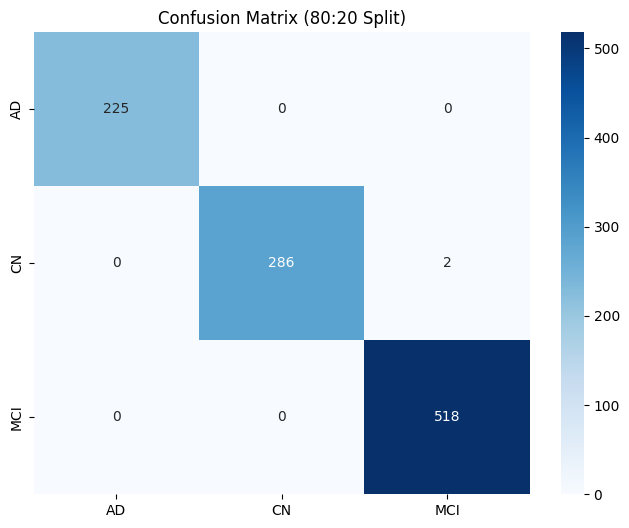

In [6]:
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(classes):
    print(f"Accuracy for {cls}: {per_class_acc[i]:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix (80:20 Split)')
plt.show()

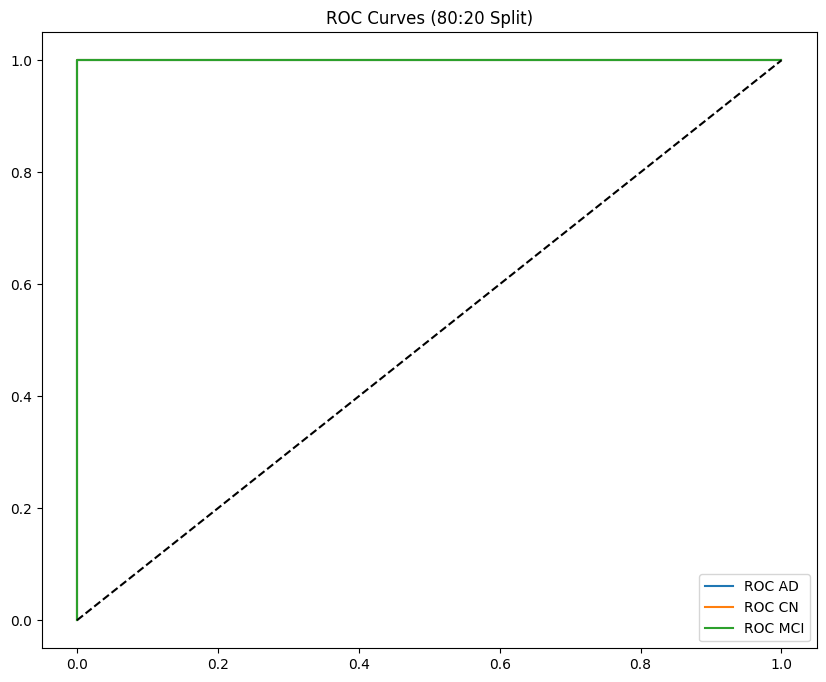

In [7]:
plt.figure(figsize=(10, 8))
y_prob_np = np.array(y_prob)
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_true, y_prob_np[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'ROC {classes[i]}')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves (80:20 Split)')
plt.legend()
plt.show()